In [ ]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "DeepUnitMatch"))
sys.path = list(set(sys.path))
from testing.test import *
import matplotlib.pyplot as plt
import pandas as pd

# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results"
RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results\N_set_by_UM"

# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results_no_conflict_filter"
# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results_no_conflict_filter\N_set_by_UM"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import seaborn as sns


def paired_violin_plot(
    M,
    labels=None,
    colors=None,
    ylabel="Value",
    figsize=(6, 5),
    jitter=0.06,
    violin_width=0.6,
    show_violin=True,
    show_points=True,
    show_mean=True,
    show_sem=True,
    alpha_lines=0.35,
    comparisons="adjacent",   # "adjacent", "all", or list of tuples
):
    """
    Parameters
    ----------
    M : ndarray
        Shape = (n_models, n_samples)

    labels : list of str
        Labels for each model.

    colors : list
        List of matplotlib colours.

    comparisons :
        "adjacent" -> compare neighbouring models
        "all" -> compare every pair
        [(0,2),(1,3)] -> custom comparisons
    """

    M = np.asarray(M)

    if M.ndim != 2:
        raise ValueError("M must have shape (n_models, n_samples).")

    n_models, n_samples = M.shape

    if labels is None:
        labels = [f"Model {i+1}" for i in range(n_models)]

    if colors is None:
        colors = sns.color_palette("tab10", n_models)

    x = np.arange(n_models)

    fig, ax = plt.subplots(figsize=figsize)

    # ---------------------------------------------------
    # Violin plots
    # ---------------------------------------------------
    if show_violin:
        vp = ax.violinplot(
            M.T,
            positions=x,
            widths=violin_width,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for body, colour in zip(vp["bodies"], colors):
            body.set_facecolor(colour)
            body.set_edgecolor("none")
            body.set_alpha(0.25)

    # ---------------------------------------------------
    # Connecting lines
    # ---------------------------------------------------
    for i in range(n_samples):
        xx = x + np.random.uniform(-jitter/3, jitter/3, n_models)
        ax.plot(xx, M[:, i],
                color="0.75",
                lw=1,
                alpha=alpha_lines,
                zorder=1)

    # ---------------------------------------------------
    # Scatter points
    # ---------------------------------------------------
    if show_points:
        for k in range(n_models):
            xx = x[k] + np.random.uniform(-jitter, jitter, n_samples)

            ax.scatter(
                xx,
                M[k],
                s=35,
                color=colors[k],
                edgecolor="none",
                zorder=3
            )

    # ---------------------------------------------------
    # Mean ± SEM
    # ---------------------------------------------------
    means = np.nanmean(M, axis=1)
    sem = np.nanstd(M, axis=1, ddof=1) / np.sqrt(n_samples)

    if show_sem:
        ax.errorbar(
            x,
            means,
            yerr=sem,
            fmt="none",
            color="black",
            lw=2,
            zorder=4
        )

    if show_mean:
        ax.scatter(
            x,
            means,
            s=70,
            facecolor="white",
            edgecolor="black",
            linewidth=2,
            zorder=5
        )

    # ---------------------------------------------------
    # Significance tests
    # ---------------------------------------------------
    if comparisons is not None:

        if comparisons == "adjacent":
            comparisons = [(i, i + 1) for i in range(n_models - 1)]

        elif comparisons == "all":
            comparisons = [
                (i, j)
                for i in range(n_models)
                for j in range(i + 1, n_models)
            ]

        ymax = np.nanmax(M)
        yrange = np.nanmax(M) - np.nanmin(M)

        if yrange == 0:
            yrange = 1

        h = 0.05 * yrange
        base = ymax + 0.05 * yrange

        for k, (i, j) in enumerate(comparisons):

            p = wilcoxon(M[i], M[j], nan_policy="omit").pvalue

            y = base + k * (2 * h)

            if p < 0.05:
                ax.plot(
                    [i, i, j, j],
                    [y, y + h, y + h, y],
                    color="black",
                    lw=1.5
                )

                ax.text(
                    (i + j) / 2,
                    y + h,
                    f"p = {p:.3g}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    style="italic"
                )

    # ---------------------------------------------------
    # Formatting
    # ---------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation = 45)
    ax.set_ylabel(ylabel)

    sns.despine()

    ax.set_xlim(-0.5, n_models - 0.5)
    ax.set_ylim(bottom=0)

    plt.tight_layout()

    return fig, ax

(0.5, 0.8923501886810963)

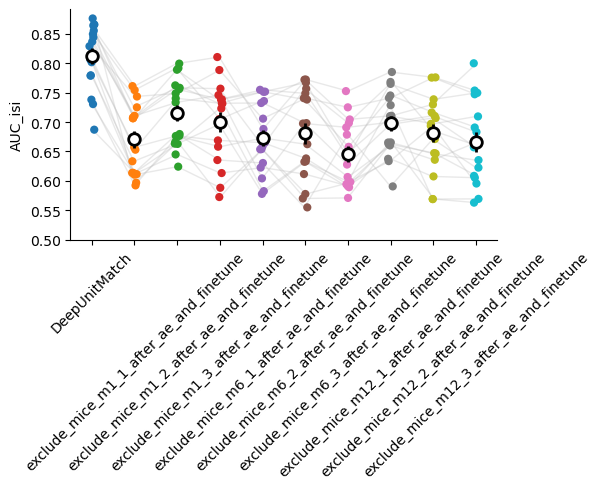

In [ ]:
models = [
          "DeepUnitMatch",
          "UMPy", 
          "EMD", 
          "DANT", 
          "DANT_no_functional",
        #   "DUM_maxdist=20", "DUM_maxdist=50", "DUM_maxdist=100", "DUM_maxdist=inf", 
        #   "UMPy_maxdist=20", "UMPy_maxdist=50", "UMPy_maxdist=100", "UMPy_maxdist=inf",
        #   "DUM_W_ij=1","DUM_W_ij=5","DUM_W_ij=10","DUM_W_ij=15","DUM_W_ij=20", 
        #   "n_output=8_after_ae_and_finetune", "n_output=32_after_ae_and_finetune", "n_output=128_after_ae_and_finetune", "n_output=256_after_ae_and_finetune", 
        #   "DUM_untrained", 
        #   "DUM_unfinetuned", "DUM_finetuned_only",
        #   "exclude_mice_m1_1_after_ae_and_finetune", "exclude_mice_m1_2_after_ae_and_finetune", "exclude_mice_m1_3_after_ae_and_finetune",
        #   "exclude_mice_m6_1_after_ae_and_finetune", "exclude_mice_m6_2_after_ae_and_finetune", "exclude_mice_m6_3_after_ae_and_finetune",
        #   "exclude_mice_m12_1_after_ae_and_finetune", "exclude_mice_m12_2_after_ae_and_finetune", "exclude_mice_m12_3_after_ae_and_finetune",
            ]


shared_columns = ["mouse", "probe", "loc", "day1", "day2", "r1", "r2", "delta_days"]
def rename_df_col(df, shared_columns, model):
    return df.rename(columns={col: f"{col}_{model}" for col in df.columns if col not in shared_columns})

# read, rename, and index each model dataframe
dfs = []
for model in models:
    dfm = (
        pd.read_csv(os.path.join(RESULTS_DIR, f"UM Probabilities_{model}_results.csv"))
          .drop_duplicates()
          .reset_index(drop=True)
    )
    dfm = rename_df_col(dfm, shared_columns, model)
    dfm = dfm.set_index(shared_columns)
    dfs.append(dfm)

# keep only rows present in all files (use join='outer' to keep union)
merged = pd.concat(dfs, axis=1, join="inner")

# compute keep: True if any model has N>19
n_cols = [f"N_{m}" for m in models]
keep = merged[n_cols].gt(19).any(axis=1)

# filter and restore columns/index
merged = merged[keep].reset_index()
    
# metric_to_plot = 'AUC_refpop_DeepUnitMatch'
# metric_to_plot = 'AUC_refpop_model'
# metric_to_plot = 'AUC_natim'
metric_to_plot = 'AUC_isi'
# metric_to_plot = 'AUC_isi_cv'
# metric_to_plot = 'AUC_fr'
# metric_to_plot = 'N'

# REPLACE NANS WITH 0.5
# df = df.fillna(0.5)

M = []
for model in models:
    avg_metric_by_mouse = merged.groupby("mouse")[f"{metric_to_plot}_{model}"].mean()
    M.append(avg_metric_by_mouse.values)

M = np.asarray(M)
M = M[:, ~np.all(np.isnan(M), axis=0)]
fig, ax = paired_violin_plot(
    M,
    labels=models,
    ylabel=metric_to_plot,
    comparisons=None,   # or "all" or [(0,3), (1,4)]
    show_violin = False,
    colors = None
)
ax.set_ylim(bottom=0.5)

In [95]:
np.any(df[keep]['N_DeepUnitMatch'] < 20)

False

In [114]:
print(np.shape(df_new))
print(np.shape(df))

(16978, 16)
(16977, 32)


In [79]:
df_new

,mouse,probe,loc,day1,day2,r1,r2,AUC_isi_exclude_mice_m1_1_after_ae_and_finetune,AUC_fr_exclude_mice_m1_1_after_ae_and_finetune,AUC_isi_cv_exclude_mice_m1_1_after_ae_and_finetune,AUC_refpop_UMPy_exclude_mice_m1_1_after_ae_and_finetune,AUC_refpop_DeepUnitMatch_exclude_mice_m1_1_after_ae_and_finetune,AUC_refpop_model_exclude_mice_m1_1_after_ae_and_finetune,AUC_natim_exclude_mice_m1_1_after_ae_and_finetune,N_exclude_mice_m1_1_after_ae_and_finetune,delta_days
0,AL031,19011116684,2,0,1,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
1,AL032,19011111882,1,0,0,1.0,2.0,0.877225,0.332019,0.306735,NaN,0.932241,0.751163,NaN,12,0
2,AV008,Probe0,IMRO_12,0,2,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2
3,AV008,Probe0,IMRO_12,0,4,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
4,AV008,Probe0,IMRO_12,0,6,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,AV009,Probe1,IMRO_10,66,77,24.0,26.0,0.894034,0.311750,0.442409,NaN,0.895036,0.914505,NaN,23,11
16974,AV009,Probe1,IMRO_10,66,92,24.0,27.0,0.907644,0.394886,0.372587,NaN,0.874170,0.906503,NaN,26,26
16975,AV009,Probe1,IMRO_10,71,77,25.0,26.0,0.910102,0.356751,0.432478,NaN,0.934075,0.855736,NaN,41,6
16976,AV009,Probe1,IMRO_10,71,92,25.0,27.0,0.877362,0.451165,0.385783,NaN,0.937166,0.853924,NaN,41,21


In [115]:
shared = shared_columns

df1 = df[shared].copy().reset_index()
df2 = df_new[shared].copy().reset_index()

diff = df1.merge(df2, on=shared, how="outer", indicator=True)

left_only = diff[diff["_merge"] == "left_only"]
right_only = diff[diff["_merge"] == "right_only"]

print("Rows only in df:")
print(left_only)

print("Rows only in df_new:")
print(right_only)

Rows only in df:
Empty DataFrame
Columns: [index_x, mouse, probe, loc, day1, day2, r1, r2, delta_days, index_y, _merge]
Index: []
Rows only in df_new:
    index_x  mouse        probe loc  day1  day2   r1   r2  delta_days  \
66      NaN  AL031  19011116684   2     0     1  1.0  2.0           1   

    index_y      _merge  
66        0  right_only  


In [17]:
avg_metric_by_mouse

mouse
AL031    0.720600
AL032    0.763354
AL036    0.778870
AV008    0.717539
AV009    0.797330
AV015    0.767670
AV021    0.695653
AV049    0.681035
CB015    0.808677
CB016    0.816245
CB017    0.914163
CB020    0.872863
EB014    0.816038
EB019    0.769118
FT033    0.705862
FT039    0.098734
JF084    0.850906
Name: AUC_isi_exclude_mice_m12_3_after_ae_and_finetune, dtype: float64